# Première idée pour la modélisation 3D

In [42]:
import parcels
import cartopy
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
from parcels import FieldSet
from datetime import timedelta
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec

# Integrate Rapid-mCDR model (OAE method) into 2D horizontal OceanParcels simulations with LL270 data

## 1) Define the Fieldset and variables required for continuous OAE simulation (alkalinity added daily in the initial cell of the ALK zero concentration field)

In [43]:
# Define the files to load depending on the time and depth
date = '1995-01'

# Define the data region and the time of the data
region = "ACC"

### 1) a. Load the U, V, W and ALK monthly fields at the desired time and depth from the LLC270 dataset

In [44]:
# Definition of NetCDF files for U, V, W and ALK
path = "/Users/margheritacastellano/Documents/These-Recherche/SEMES/data"
filenames = {
    "U": f"{path}/UVEL_{date}_equal.nc",
    "V": f"{path}/VVEL_{date}_equal.nc",
    "W": f"{path}/WVEL_{date}.nc",
    "ALK": f"{path}/ALK_{date}.nc"
}

# Definition of variables and dimensions
variables = {
    "U": "UVEL",
    "V": "VVEL",
    "W": "WVEL",
    "ALK": "ALK"
}

dimensions = {
    "U": {"depth": "Depth", "lat": "Latitude", "lon": "Longitude", "time": "Time"},
    "V": {"depth": "Depth", "lat": "Latitude", "lon": "Longitude", "time": "Time"},
    "W": {"depth": "Depth", "lat": "Latitude", "lon": "Longitude", "time": "Time"},
    "ALK": {"depth": "Depth", "lat": "Latitude", "lon": "Longitude", "time": "Time"}
}

# Create the FieldSet for velocities U, V and W as well as the ALK concentration fields on an Arakawa C grid
fieldset = FieldSet.from_netcdf(
    filenames,
    variables,
    dimensions,
    mesh="spherical",
    allow_time_extrapolation=True
)

# Define the interpolation method for the UV velocity fields
fieldset.UV.interp_method = "cgrid_velocity"

# ALK0 (the alkalinity PERTURBATION field) is built on the same grid as ALK, starting from zero
depth_C = fieldset.ALK.data.shape[1]
lon_C = fieldset.ALK.data.shape[3]
lat_C = fieldset.ALK.data.shape[2]

# Create a field full of zeros for the particle simulation in ALK0 field
data_alk0 = np.zeros([depth_C, lat_C, lon_C])
field_alk0 = parcels.Field("ALK0", data_alk0, grid=fieldset.ALK.grid)
fieldset.add_field(field_alk0)


# Convert the fields to float64
for f in [fieldset.U, fieldset.V, fieldset.W, fieldset.ALK0, fieldset.ALK]:
    f.data = f.data.astype(np.float64)

# (ALK0 is reconstructed from the per-particle columns and written per day in the
# run loop via fieldset.ALK0.write(...), so parcels' automatic field writing is off.)

K_diff_vertical_v = [1.0125125e-05, 8.9139901e-03, 2.7745981e-03, 6.6304987e-04, 2.4509168e-04,
7.1794559e-05, 1.4329043e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05,
1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05,
1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05,
1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05,
1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05,
1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05,
1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05,
1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05,
1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05]

# Dose d'alcalinite injectee en surface, en meq/(m^3 s).
fieldset.add_constant("alkalinity_forcing", 0.000012409)


In [45]:
# --- Finite-volume vertical grid geometry for the combined implicit
#     advection + diffusion scheme (stored on the fieldset as constants) ---
# ALK / ALK0 live at cell CENTERS while the vertical velocity W
# lives at the cell TOP FACES (vertical Arakawa-C staggering).
RC = np.abs(fieldset.ALK.grid.depth.astype(np.float64))   # cell-center depth 
RF = np.abs(fieldset.W.grid.depth.astype(np.float64))     # cell top-face depth

h_fv     = 2.0 * (RC - RF)     # finite volume
delta_fv = np.diff(RC)         # center-to-center distance, one per interior interface (BC at the exterior ones!)

# Diffusivity at each interface = arithmetic mean of the two adjacent cell values.
Kint_fv = np.zeros_like(RC)
Kint_fv[1:] = 0.5 * (np.asarray(K_diff_vertical_v)[:-1] + np.asarray(K_diff_vertical_v)[1:])

fieldset.add_constant("h_fv", h_fv)          # (Nz,)   cell thicknesses
fieldset.add_constant("delta_fv", delta_fv)  # (Nz-1,) center-to-center distances
fieldset.add_constant("Kint_fv", Kint_fv)    # (Nz,)   interface diffusivities (index 0 unused)

print("Finite-volume geometry ready: Nz =", len(RC),
      "| explicit diffusion number D =",
      round(float(np.max(K_diff_vertical_v)) * 86400.0 / float(h_fv.min()) ** 2, 2))


Finite-volume geometry ready: Nz = 50 | explicit diffusion number D = 7.7


## 2) Define Kernels for the continuous OAE simulation with OceanParcels

### Les kernels

Deux anciens kernels ont disparu, et c'est volontaire :

- **`RapidmCDRModel`** (transport horizontal par echange de colonnes sur un champ **partage**) :
  supprime. Chaque particule porte desormais **sa propre** colonne (`fieldset.pcol[pidx]`), donc
  aucun echange entre mailles n'est necessaire -- ce qui elimine la *cascade* (les echanges
  sequentiels entre particules relayaient une colonne vers l'avant et empilaient l'alcalinite sur
  la maille de tete).
- **`AdvectionParticle`** (RK4 maison base sur `lon_nextloop`) : remplace par le kernel integre
  **`parcels.AdvectionRK4`**, robuste. Les particules sont lachees a **5 m** (1er niveau de
  vitesse) : a 0 m, U/V seraient echantillonnes au-dessus de leur niveau le plus haut
  (hors-bornes) et la particule n'avancerait jamais.

Il ne reste donc qu'**un seul** kernel maison : `VerticalAdvDiffImplicit` (ci-dessous).
Voir `SCHEMA_NUMERIQUE.md` pour les maths et l'algorithme.

In [46]:
def VerticalAdvDiffImplicit(particle, fieldset, time):
    """
    ADVECTION + DIFFUSION VERTICALES pour la particule en entrée : volumes finis 1D,
    Euler implicite. On assemble la matrice tridiagonale A et on resout  A c^{n+1} = c^n.

    Chaque particule porte sa propre colonne fieldset.pcol[particle.pidx] ; le schema
    agit sur cette colonne privee, avec la vitesse verticale de la maille ou se trouve
    la particule.

    Geometrie (construite dans la cellule de setup, stockee sur le fieldset) :
        h_fv[k]     : epaisseur de la maille k       = 2*(RC[k]-RF[k])
        delta_fv[i] : distance centre-a-centre       = RC[i]-RC[i-1]   (i=1..Nz-1)
        Kint_fv[i]  : diffusivite a l'interface i    = (K[i-1]+K[i])/2
    """
    import numpy as np

    dt = particle.dt
    _ = fieldset.UV[particle]

    xi, yi = particle.xi[fieldset.V.igrid], particle.yi[fieldset.U.igrid]
    # Correction of indexes if necessary
    if abs(particle.lon - fieldset.V.grid.lon[yi, xi + 1]) < abs(particle.lon - fieldset.V.grid.lon[yi, xi]):
        xi += 1
    if abs(particle.lat - fieldset.U.grid.lat[yi + 1, xi]) < abs(particle.lat - fieldset.U.grid.lat[yi, xi]):
        yi += 1
    if abs(particle.lon - fieldset.V.grid.lon[yi, xi - 1]) < abs(particle.lon - fieldset.V.grid.lon[yi, xi]):
        xi -= 1
    if abs(particle.lat - fieldset.U.grid.lat[yi - 1, xi]) < abs(particle.lat - fieldset.U.grid.lat[yi, xi]):
        yi -= 1
    particle.cell_x = xi     # maille courante (sert a reconstruire le champ ALK0)
    particle.cell_y = yi

    Nz = fieldset.ALK0.data.shape[1]
    c = fieldset.pcol[particle.pidx].copy()      # La colonne propre a cette particule
    W = fieldset.W.data[0, :, yi, xi].copy()     # vitesse verticale a la maille courante
    h = fieldset.h_fv
    delta = fieldset.delta_fv
    Kint = fieldset.Kint_fv

    # Garde-fous terre / valeurs de remplissage sous le plancher -> w = 0 (flux nul)
    W = np.where(np.isfinite(W), W, 0.0)
    W = np.where(np.abs(W) > 1.0, 0.0, W)

    # Forcage de surface : une dose quotidienne, le jour du lacher uniquement
    if particle.released == 0:
        c[0] += fieldset.alkalinity_forcing * dt
        particle.released = 1

    # ---- coefficients aux interfaces (i = face du haut de la maille i) ----
    a_down = np.maximum(-W, 0.0)      # vitesse descendante
    a_up = np.maximum(+W, 0.0)        # vitesse montante
    Kd = np.zeros(Nz)
    Kd[1:] = Kint[1:] / delta         # K_i / delta_i
    a_down[0] = 0.0                   # interface 0 = surface -> flux nul
    a_up[0] = 0.0
    Kd[0] = 0.0

    # ---- les 4 coefficients de chaque maille k ----
    A_k = a_down + Kd                                    # coeff de c_{k-1}  (entree par le haut)
    B_k = a_up + Kd                                      # perte par le haut
    C_k = np.zeros(Nz)
    C_k[:-1] = a_down[1:] + Kd[1:]                       # perte par le bas
    D_k = np.zeros(Nz)
    D_k[:-1] = a_up[1:] + Kd[1:]                         # coeff de c_{k+1}  (entree par le bas)
    # C_k[-1] = D_k[-1] = 0  ->  interface du fond : flux nul

    # ---- assemblage de A et resolution de  A c^{n+1} = c^n ----
    r = dt / h
    diag = 1.0 + r * (B_k + C_k)
    sub = -r[1:] * A_k[1:]                               # A[k, k-1]
    sup = -r[:-1] * D_k[:-1]                             # A[k, k+1]
    Amat = np.diag(diag) + np.diag(sub, -1) + np.diag(sup, 1)

    fieldset.pcol[particle.pidx] = np.linalg.solve(Amat, c)


## 3) Run the OceanParcels simulation with the Rapid-mCDR model to simulate the continuous OAE method 

### 3) a. Select the particle to track and the Kernel (Transport + OAE Method)

In [47]:
### Select the Particle to track and the Kernel (Transport + Conservation Methods) ###
position = (-2, -49)  # Initial position of the particle (longitude, latitude)
last_time = 31  # Number of days to run the simulation

In [48]:
# Definition of the particle and variables to track
class Particle(parcels.ScipyParticle):
    forcing_alk = parcels.Variable('f_alk', dtype=np.float64, initial=fieldset.alkalinity_forcing) # Additional alkalinity forcing (in meq/(m^3 s))
    cell_x = parcels.Variable('cell_x', dtype=np.int32, initial=-1)  # current grid cell (longitude index)
    cell_y = parcels.Variable('cell_y', dtype=np.int32, initial=-1)  # current grid cell (latitude index)
    released = parcels.Variable('released', dtype=np.int32, initial=0)  # 0 until this particle has deposited its daily alkalinity dose
    pidx = parcels.Variable('pidx', dtype=np.int32, initial=0)  # row of this particle's own column in fieldset.pcol

# Per-particle vertical alkalinity columns: row p holds the column carried by particle p.
fieldset.pcol = np.zeros((last_time, fieldset.ALK0.data.shape[1]))

# Release depth = first velocity level. U and V live at cell centres: the first ones are at 5 m from the surface.
release_depth = 5.0

# Creation of a particle set (first particle, pidx = 0, released at t = 0)
pset = parcels.ParticleSet(fieldset=fieldset, pclass=Particle,
                           lon=[position[0]], lat=[position[1]],
                           depth=[release_depth], time=[0.0])


### 3) b. Run the simulation during 1 month with 1 addition of ALK flux every day to the surface of the initial cell

In [49]:
import os, shutil

# Define the folder name to save the results
folder = "Test"
filename_save = f"{folder}/DailyRapidmCDR_LLC270_ACC_{date}"

# On repart d'un dossier de sortie propre. Ce nettoyage est VOLONTAIREMENT place ici,
# juste avant le run : vider et regenerer sont ainsi indissociables. (Quand c'etait une
# cellule separee en haut du notebook, la relancer seule effacait les resultats sans
# les reproduire.)
if os.path.isdir(folder):
    shutil.rmtree(folder)
os.makedirs(folder, exist_ok=True)

# Trajectory output (particle positions). 
output_file = pset.ParticleFile(name=f"{filename_save}.zarr", outputdt=timedelta(days=1))

# Kernels: per-particle vertical adv-diff + horizontal RK4 advection.
kernels = pset.Kernel(VerticalAdvDiffImplicit) + pset.Kernel(parcels.AdvectionRK4)


# Days on which to save a full-depth ALK0 field snapshot.
snapshot_days = [1, 5, 13, last_time]

def save_ALK0_snapshot(day_index):
    """On selected days, reconstruct the ALK0 field by placing each particle's column at
    its current grid cell, then write Test/..._{NNNN}ALK0.nc used by the plots."""
    if day_index not in snapshot_days:
        return
    fieldset.ALK0.data[:] = 0.0     # on repart de zéro : le champ ne sert qu'à l'affichage
    for p in pset:
        if p.cell_x >= 0: # on ne regarde que les particules qui ont déjà été localisées (les autres valent -1)
            fieldset.ALK0.data[0, :, p.cell_y, p.cell_x] += fieldset.pcol[p.pidx] # on dépose la colonne de p à sa maille
    fieldset.ALK0.write(f"{filename_save}_{day_index:04d}")


# Day 0: release the first particle, advance ONE day, save snapshot 0001
pset.execute(kernels, dt=timedelta(days=1), runtime=timedelta(days=1), output_file=output_file)
save_ALK0_snapshot(1)

# Each following day: release a NEW particle (its own column row pidx=day), advance one day
for day in range(1, last_time):
    print(f"Day {day}: injecting a new particle at {position}; advancing all active particles by 1 day")

    new_particle = parcels.ParticleSet(
        fieldset=fieldset, pclass=Particle,
        lon=[position[0]], lat=[position[1]],
        depth=[release_depth], time=[day * 86400.0],
    )
    new_particle.pidx[:] = day          # this particle uses column row 'day' of fieldset.pcol
    pset.add(new_particle)

    pset.execute(kernels, dt=timedelta(days=1), runtime=timedelta(days=1), output_file=output_file)
    save_ALK0_snapshot(day + 1)


INFO: Output files are stored in Test/DailyRapidmCDR_LLC270_ACC_1995-01.zarr.
100%|██████████| 86400.0/86400.0 [00:01<00:00, 50856.38it/s]
Day 1: injecting a new particle at (-2, -49); advancing all active particles by 1 day
INFO: Output files are stored in Test/DailyRapidmCDR_LLC270_ACC_1995-01.zarr.
100%|██████████| 86400.0/86400.0 [00:01<00:00, 57999.59it/s]
Day 2: injecting a new particle at (-2, -49); advancing all active particles by 1 day
INFO: Output files are stored in Test/DailyRapidmCDR_LLC270_ACC_1995-01.zarr.
100%|██████████| 86400.0/86400.0 [00:01<00:00, 60047.07it/s]
Day 3: injecting a new particle at (-2, -49); advancing all active particles by 1 day
INFO: Output files are stored in Test/DailyRapidmCDR_LLC270_ACC_1995-01.zarr.
100%|██████████| 86400.0/86400.0 [00:01<00:00, 58306.45it/s]
Day 4: injecting a new particle at (-2, -49); advancing all active particles by 1 day
INFO: Output files are stored in Test/DailyRapidmCDR_LLC270_ACC_1995-01.zarr.
100%|██████████| 86400

## 4) Load and visualize the results of the continuous OAE simulation

In [50]:
# Define the folder name to load the results
filename = f"Test/DailyRapidmCDR_LLC270_ACC_{date}"

# Load the results
pset_traj = xr.open_zarr(f"{filename}.zarr")
# pset_traj = open_sparse_zarr(f"{filename_save}.zarr")

figure sauvegardee -> figures/trajectoires.png


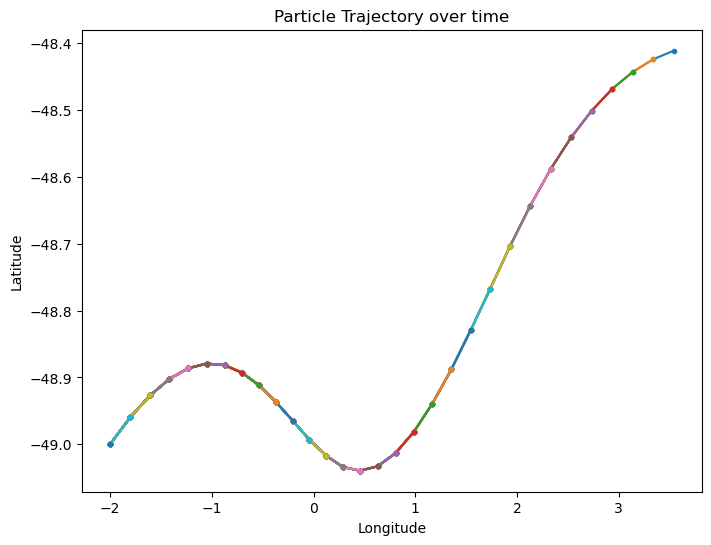

In [51]:
%matplotlib inline
# Plot the particle trajectories
plt.figure(figsize=(8, 6))
plt.plot(pset_traj["lon"].T, pset_traj["lat"].T, ".-")
plt.title("Particle Trajectory over time")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
# --- sauvegarde de la figure ---
import os
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/trajectoires.png", dpi=150, bbox_inches="tight")
print("figure sauvegardee -> figures/trajectoires.png")

plt.show()

### Plot the ALK0 concentration field at the beginning and the end of the continuous OAE simulation (one ALK dose addedeach day at the initial cell)

In [52]:
# Define the extent to zoom in on the area of interest
extent = [-3, 5, -50, -48]

# Define the coordinates for the grid
lon = fieldset.V.grid.lon
sample_x = fieldset.U.grid.lon[lon.shape[0]*3//4, :][(fieldset.U.grid.lon[lon.shape[0]*3//4, :] >= extent[0]) & (fieldset.U.grid.lon[lon.shape[0]*3//4, :] <= extent[1])][::2]
sample_y = fieldset.V.grid.lat[:, lon.shape[1]//2][(fieldset.V.grid.lat[:, lon.shape[1]//2] >= extent[2]) & (fieldset.V.grid.lat[:, lon.shape[1]//2] <= extent[3])][::2]

In [39]:
print(f"Concentration of alk forcing particle added to initial cell over time (meq/(m^3s)) : \n {pset_traj['f_alk'].values[0]}")

Concentration of alk forcing particle added to initial cell over time (meq/(m^3s)) : 
 [1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05
 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05
 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05
 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05
 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05
 1.2409e-05]


In [ ]:
# Define the variable to display
var_name = "ALK0"
particle_name = "f_alk"

# Select the days to display
dayFirst = "0005"
# dayLast = "0496"
dayLast = "0031"

# Load the NetCDF files for each specified days
first = xr.open_dataset(f"{filename}_{dayFirst}{var_name}.nc")
last = xr.open_dataset(f"{filename}_{dayLast}{var_name}.nc")

depth = 0          # INDICE de niveau (pas des metres !) : 0 -> 5 m, 1 -> 15 m, 4 -> 45 m

echelle_commune = True   # True = MEME colorbar pour les 2 panneaux (indispensable pour comparer)

prof = np.abs(fieldset.ALK.grid.depth)   # profondeur reelle de chaque niveau

# .copy() : sinon on modifierait en place le tableau du dataset
fieldF = first[f"{var_name}"].values[0, depth, :, :].copy()
fieldL = last[f"{var_name}"].values[0, depth, :, :].copy()

# On masque les mailles jamais touchees (elles valent exactement 0) -> fond blanc.
# Les DEUX panneaux sont masques de la MEME facon, sinon ils ne sont pas comparables.
fieldF[fieldF == 0] = np.nan
fieldL[fieldL == 0] = np.nan

# Echelle commune : on prend le max des DEUX jours
if echelle_commune:
    vmin, vmax = 0.0, np.nanmax([np.nanmax(fieldF), np.nanmax(fieldL)])
else:
    vmin = vmax = None

# Extract longitude and latitude coordinates
longitudes = first["nav_lon"].values
latitudes = first["nav_lat"].values

%matplotlib inline
fig, axes = plt.subplots(ncols=2, figsize=(20, 6), subplot_kw={'projection': ccrs.PlateCarree()})
fig.suptitle(f"Rapid-mCDR : champ {var_name} a {prof[depth]:.0f} m (niveau {depth}) — deux jours"
             + ("  (echelle commune)" if echelle_commune else "  (ECHELLES INDEPENDANTES : ne pas comparer les couleurs !)"),
             fontsize=14)

end_simu = int(dayLast)%last_time
for ax, field_day, title in zip(axes, [fieldF, fieldL], [f"Day {dayFirst[-2:]}", f"Day {[end_simu + 31 if end_simu == 0 else end_simu][0]}"]):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, edgecolor="black", facecolor="floralwhite")
    ax.set_title(f"{title}")

    # Display the concentration data
    results = ax.pcolormesh(longitudes, latitudes, field_day, transform=ccrs.PlateCarree(),
                            cmap="cividis", vmin=vmin, vmax=vmax)
    ax.plot(position[0], position[1], "r*", markersize=15, transform=ccrs.PlateCarree(), zorder=5)
    
    # Add a colorbar for each concentration field
    cbar = fig.colorbar(results, ax=ax, orientation="vertical", fraction=0.05)
    cbar.set_label(f"{var_name} Concentration (µM ALK)")

    # Add gridlines and labels
    ax.set_xticks(sample_x, crs=ccrs.PlateCarree())
    ax.set_yticks(sample_y, crs=ccrs.PlateCarree())
    ax.set_xticklabels([f"{lon:.1f}°" for lon in sample_x], rotation=45)
    ax.set_yticklabels([f"{lat:.1f}°" for lat in sample_y])
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    for i in range(lon.shape[0]):
        ax.plot(fieldset.V.grid.lon[i, :], fieldset.V.grid.lat[i, :], color='gray', linewidth=1.1, linestyle='--', transform=ccrs.PlateCarree(), alpha=0.6)
    for j in range(lon.shape[1]):
        ax.plot(fieldset.U.grid.lon[:, j], fieldset.U.grid.lat[:, j], color='gray', linewidth=1.1, linestyle='--', transform=ccrs.PlateCarree(), alpha=0.6)

# # Display particles as scatter points on the first plot
# particle = axes[0].scatter(
#     pset_traj["lon"].values[0], pset_traj["lat"].values[0], c=pset_traj[f"{particle_name}"].values[0], transform=ccrs.PlateCarree(),
#     s=100, edgecolor="white", cmap="gist_earth"
# )
# 
# # Add a colorbar for particle concentration
# particle_cbar = plt.colorbar(particle, ax=axes[0], orientation="horizontal")
# particle_cbar.set_label(f"Transport of alkalinity {particle_name} added to initial cell over time in zero alkalinity field (meq/(m² s))", fontsize=12)

plt.tight_layout()

# --- sauvegarde de la figure (le nom encode les parametres, pour ne rien ecraser) ---
import os
os.makedirs("figures", exist_ok=True)
nom_fig = f"figures/{var_name}_jour{dayFirst}_vs_jour{dayLast}_niveau{depth}.png"
plt.savefig(nom_fig, dpi=150, bbox_inches="tight")
print(f"figure sauvegardee -> {nom_fig}")

plt.show()

### Comparer DEUX PROFONDEURS au MEME jour

Complementaire de la carte precedente (qui compare deux jours a une profondeur).

Ici on fige le jour et on regarde **deux niveaux verticaux cote a cote** : c'est ce qui
montre le gradient vertical, donc l'effet de la diffusion.

> **`echelle_commune = True`** est essentiel. Si chaque panneau auto-ajuste son echelle,
> le "jaune" d'un panneau peut valoir moins que le "bleu" de l'autre : comparer les
> couleurs devient alors trompeur.

figure sauvegardee -> figures/ALK0_jour0031_niveaux0-4.png

Gradient vertical 5m / 45m :
   a la source   : 0.750 / 0.092  -> rapport 8.1x
   rapport median sur toute la trainee : 1.14x
   (proche de 1 = colonne homogeneisee ; grand = dose fraiche encore en surface)


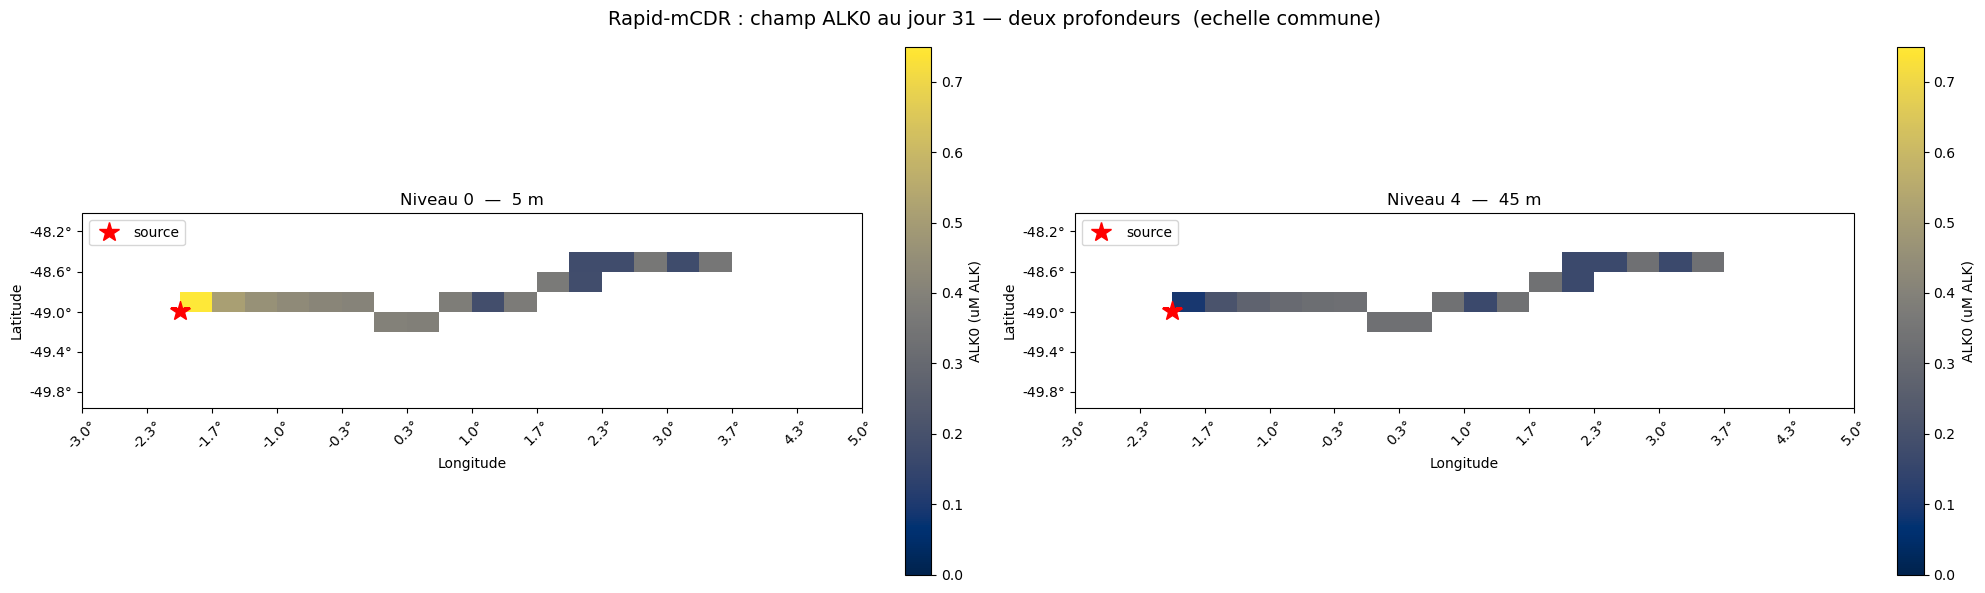

In [54]:
# ---- Comparer deux PROFONDEURS au meme jour ----
jour     = "0031"      # doit etre dans snapshot_days (4 chiffres)
niveau_A = 0           # panneau de GAUCHE  -> 5 m
niveau_B = 4           # panneau de DROITE  -> 45 m

echelle_commune = True   # True = MEME colorbar pour les 2 panneaux (indispensable pour comparer)

# Profondeur reelle de chaque niveau (centres de maille, lus depuis la vraie grille)
prof = np.abs(fieldset.ALK.grid.depth)

ds     = xr.open_dataset(f"{filename}_{jour}{var_name}.nc")
champ  = ds[var_name].values[0]          # (50, y, x)
lon_2d = ds["nav_lon"].values
lat_2d = ds["nav_lat"].values

# On masque les mailles jamais touchees (elles valent exactement 0) -> fond blanc
cartes = []
for lv in (niveau_A, niveau_B):
    c = champ[lv].copy()
    c[c == 0] = np.nan
    cartes.append(c)

# Echelle commune : on prend le max des DEUX niveaux
if echelle_commune:
    vmin, vmax = 0.0, np.nanmax([np.nanmax(c) for c in cartes])
else:
    vmin = vmax = None

%matplotlib inline
fig, axes = plt.subplots(ncols=2, figsize=(20, 6), subplot_kw={"projection": ccrs.PlateCarree()})
fig.suptitle(f"Rapid-mCDR : champ {var_name} au jour {int(jour)} — deux profondeurs"
             + ("  (echelle commune)" if echelle_commune else "  (echelles independantes !)"),
             fontsize=14)

for ax, carte, lv in zip(axes, cartes, (niveau_A, niveau_B)):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, edgecolor="black", facecolor="floralwhite")
    ax.set_title(f"Niveau {lv}  —  {prof[lv]:.0f} m")

    res = ax.pcolormesh(lon_2d, lat_2d, carte, transform=ccrs.PlateCarree(),
                        cmap="cividis", vmin=vmin, vmax=vmax)
    ax.plot(position[0], position[1], "r*", markersize=15,
            transform=ccrs.PlateCarree(), label="source")

    cbar = fig.colorbar(res, ax=ax, orientation="vertical", fraction=0.05)
    cbar.set_label(f"{var_name} (uM ALK)")

    ax.set_xticks(sample_x, crs=ccrs.PlateCarree())
    ax.set_yticks(sample_y, crs=ccrs.PlateCarree())
    ax.set_xticklabels([f"{v:.1f}°" for v in sample_x], rotation=45)
    ax.set_yticklabels([f"{v:.1f}°" for v in sample_y])
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.legend(loc="upper left")

plt.tight_layout()

import os
os.makedirs("figures", exist_ok=True)
nom = f"figures/{var_name}_jour{jour}_niveaux{niveau_A}-{niveau_B}.png"
plt.savefig(nom, dpi=150, bbox_inches="tight")
print(f"figure sauvegardee -> {nom}")

# Le gradient vertical, en chiffres (c'est LA quantite interessante)
a, b = cartes[0], cartes[1]
m = ~np.isnan(a) & ~np.isnan(b)
print(f"\nGradient vertical {prof[niveau_A]:.0f}m / {prof[niveau_B]:.0f}m :")
print(f"   a la source   : {np.nanmax(a):.3f} / {b[a == np.nanmax(a)][0]:.3f}"
      f"  -> rapport {np.nanmax(a)/b[a == np.nanmax(a)][0]:.1f}x")
print(f"   rapport median sur toute la trainee : {np.median(a[m]/b[m]):.2f}x")
print("   (proche de 1 = colonne homogeneisee ; grand = dose fraiche encore en surface)")

plt.show()


### Volume-weighted mass-conservation check (advection + diffusion)

The finite-volume scheme conserves the **volume-weighted** column mass
$\sum_k h_k\,C_k$. It should equal the total alkalinity injected into the
surface cell, $h_0\cdot\text{forcing}\cdot\Delta t$ per injection.

In [35]:
# Volume-weighted conservation check for the finite-volume adv-diff scheme.
# h_fv = tracer cell thicknesses (from the finite-volume setup cell). The scheme
# conserves the volume-weighted column mass  sum_k h_k*C_k  (NOT the raw sum of
# concentrations, because cell thickness varies strongly with depth).
field_last = last[f"{var_name}"].values[0, :, :, :]        # (depth, y, x) final ALK0
mass_model = np.nansum(h_fv[:, None, None] * field_last)    # sum_k h_k * C_k  [uM*m]

mass_per_injection = h_fv[0] * fieldset.alkalinity_forcing * timedelta(days=1).total_seconds()
print(f"Volume-weighted model mass  sum(h_k*C_k) = {mass_model:.6e} uM*m")
print(f"Mass per surface injection  h0*forcing*dt = {mass_per_injection:.6e} uM*m")
print(f"=> effective number of surface injections = {mass_model / mass_per_injection:.3f}  (expected ~ last_time = {last_time})")

# A new particle is injected at the source each day and deposits one dose on its
# release day (particle.released flag), so the effective count should equal the
# number of simulated days. The finite-volume transport conserves mass exactly, so
# sum(h_k*C_k) = last_time * h0*forcing*dt.


Volume-weighted model mass  sum(h_k*C_k) = 1.393779e+02 uM*m
Mass per surface injection  h0*forcing*dt = 1.072138e+01 uM*m
=> effective number of surface injections = 13.000  (expected ~ last_time = 31)
